This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [ ]:
!pip install keras keras-hub --upgrade -q

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [ ]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Timeseries forecasting

### Different kinds of timeseries tasks

### A temperature forecasting example

In [2]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-06-02 12:00:26--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.213.131, 52.217.124.200, 16.15.237.165, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.213.131|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  49.5MB/s    in 0.3s    

2026-06-02 12:00:26 (49.5 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [3]:
import pandas as pd
df = pd.read_csv('/content/jena_climate_2009_2016.csv')
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [4]:
# 1. Отбросить колонку 'Date Time'
# df = df.drop('Date Time', axis=1)

# 2. Присвоить колонку 'T (degC)' массиву temperature
temperature = df['T (degC)'].values

# 3. Остальные колонки (кроме Date Time и T (degC)) присвоить raw_data
raw_data = df.drop(['Date Time', 'T (degC)'], axis=1).values

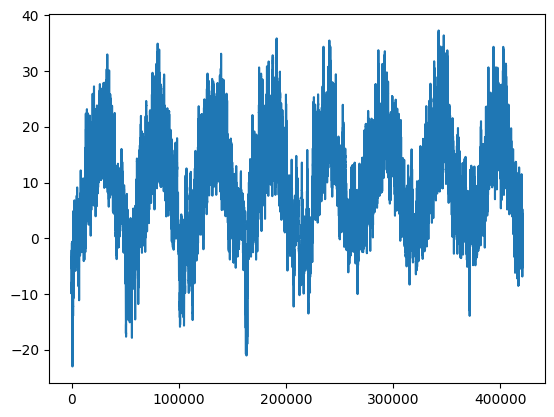

In [5]:
from matplotlib import pyplot as plt

plt.plot(range(len(temperature)), temperature)

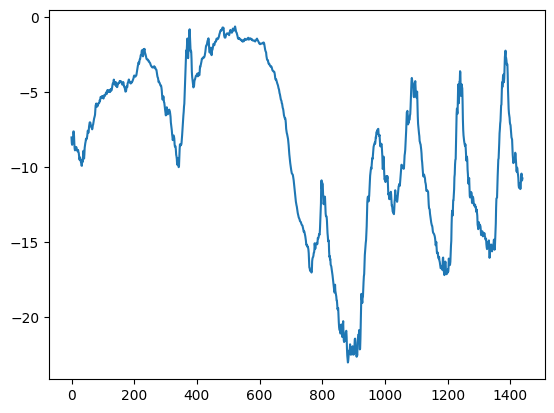

In [6]:
plt.plot(range(1440), temperature[:1440])

In [7]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples   = int(0.25 * len(raw_data))
num_test_samples  = len(raw_data) - num_train_samples - num_val_samples

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


#### Preparing the data

In [8]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

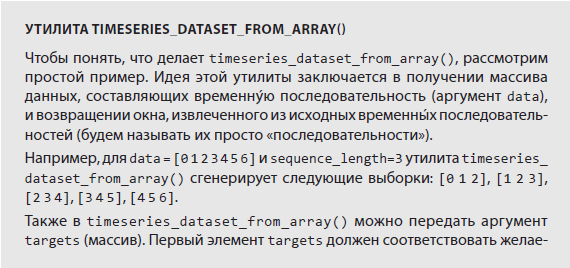

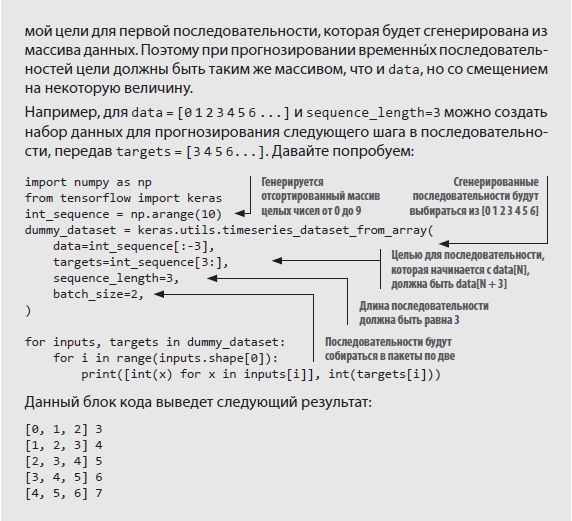

In [16]:
# просто отвлеченный пример
import numpy as np
from tensorflow import keras

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data            = int_sequence[:-3],  # исчтоник и диапазон в нем для выборок
    targets         = int_sequence[3:],   # исчтоник и диапазон в нем для целей
    sequence_length = 3,
    batch_size      = 1,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


In [17]:
for inputs, targets in dummy_dataset:
    print(f"inputs shape: {inputs.shape}")
    print(f"inputs:\n{inputs.numpy()}")
    print(f"targets shape: {targets.shape}")
    print(f"targets: {targets.numpy()}")
    print("-" * 30)

inputs shape: (1, 3)
inputs:
[[0 1 2]]
targets shape: (1,)
targets: [3]
------------------------------
inputs shape: (1, 3)
inputs:
[[1 2 3]]
targets shape: (1,)
targets: [4]
------------------------------
inputs shape: (1, 3)
inputs:
[[2 3 4]]
targets shape: (1,)
targets: [5]
------------------------------
inputs shape: (1, 3)
inputs:
[[3 4 5]]
targets shape: (1,)
targets: [6]
------------------------------
inputs shape: (1, 3)
inputs:
[[4 5 6]]
targets shape: (1,)
targets: [7]
------------------------------


In [18]:
# Преобразовать в список батчей
batches = list(dummy_dataset)

# Доступ к конкретному батчу
first_batch_inputs, first_batch_targets = batches[0]

# Преобразовать тензоры в NumPy
inputs_np = first_batch_inputs.numpy()
targets_np = first_batch_targets.numpy()

print(f"inputs_np:\n{inputs_np}")  # [[0 1 2] [1 2 3]]
print(f"targets_np: {targets_np}")  # [3 4]

inputs_np:
[[0 1 2]]
targets_np: [3]


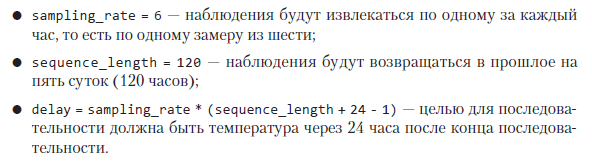

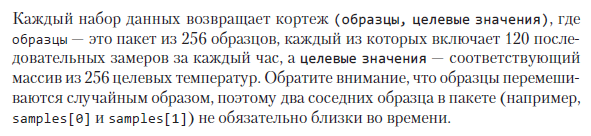

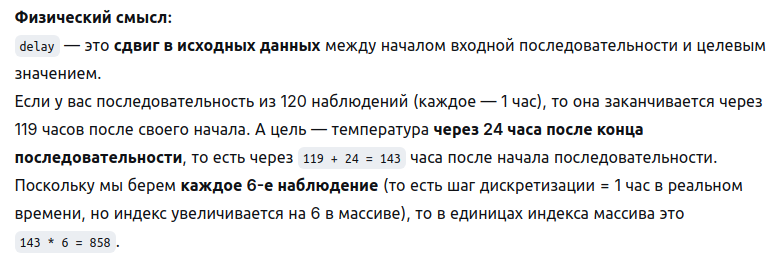

In [20]:
# наблюдения будут извлекаться по одному за каждый час, то есть по одному замеру из шести;
sampling_rate     = 6

# наблюдения будут возвращаться в прошлое на пять суток (120 часов);
sequence_length   = 120

# цель: температура через 24 часа после конца последовательности,
# через delay от начала последовательности до цели
# 24 - цель после конца выборки (просто так решили, могло быть 1, или 5)
delay             = sampling_rate * (sequence_length + 24 - 1)

batch_size        = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    data            = raw_data[:-delay],    # обрезаем хвост, чтобы для последней последовательности была цель
    targets         = temperature[delay:],  # цель для начала последовательности сдвинута на delay
    sampling_rate   = sampling_rate,
    sequence_length = sequence_length,
    # Формирование батчей: Когда вы устанавливаете shuffle=True, это означает,
    # что порядок батчей будет перемешан после их формирования.
    # Однако внутри каждого батча последовательности остаются в правильном порядке.
    # То есть, каждая последовательность (или временной отрезок) будет представлять собой непрерывный фрагмент данных
    shuffle         = True,
    batch_size      = batch_size,
    start_index     = 0,
    end_index       = num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    data            = raw_data[:-delay],    # полный диапазон из которого будут нарезаться выборки
    targets         = temperature[delay:],  # полный диапазон из которого будут нарезаться цели
    sampling_rate   = sampling_rate,
    sequence_length = sequence_length,
    shuffle         = True,
    batch_size      = batch_size,
    start_index     = num_train_samples,
    end_index       = num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    data            = raw_data[:-delay],
    targets         = temperature[delay:],
    sampling_rate   = sampling_rate,
    sequence_length = sequence_length,
    shuffle         = True,
    batch_size      = batch_size,
    start_index     = num_train_samples + num_val_samples,
)
# Каждый набор данных возвращает кортеж (образцы, целевые значения), где образцы — это пакет из 256 образцов,
# каждый из которых включает 120 после¬довательных замеров за каждый час,
# а целевые значения — соответствующий массив из 256 целевых температур.
# Обратите внимание, что образцы перемеши¬ваются случайным образом, поэтому два соседних образца
# в пакете (например, samples[0] и samples[1]) не обязательно близки во времени

#### A commonsense, non-machine-learning baseline

In [ ]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

#### Let's try a basic machine learning model

In [ ]:
import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

In [ ]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

#### Let's try a 1D convolutional model

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

### Recurrent neural networks

In [22]:
# inputs  = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
# x       = keras.layers.LSTM(16)(inputs)
# outputs = keras.layers.Dense(1)(x)
# model   = keras.Model(inputs, outputs)
model = keras.models.Sequential(
    [
        keras.layers.Input(shape=(sequence_length, raw_data.shape[-1])),
        keras.layers.LSTM(16),
        keras.layers.Dense(1)
    ]
)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam",
              loss="mse",
              metrics=["mae"]
)
history = model.fit(train_dataset,
                    epochs=5,
                    validation_data=val_dataset,
                    callbacks=callbacks,
)

model = keras.models.load_model("jena_lstm.keras")
print("Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 119s 143ms/step - loss: 48.8546 - mae: 5.1565 - val_loss: 18.6200 - val_mae: 3.2063
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 111s 135ms/step - loss: 14.9045 - mae: 2.9215 - val_loss: 11.5900 - val_mae: 2.5928
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 112s 136ms/step - loss: 11.2467 - mae: 2.5894 - val_loss: 10.2636 - val_mae: 2.4656
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 143s 174ms/step - loss: 10.3124 - mae: 2.4959 - val_loss: 9.8222 - val_mae: 2.4277
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 117s 142ms/step - loss: 10.0344 - mae: 2.4601 - val_loss: 9.8613 - val_mae: 2.4401
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 149s 152ms/step - loss: 9.6599 - mae: 2.4154 - val_loss: 9.7804 - val_mae: 2.4414
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 124s 151ms/step - loss: 9.4281 - mae: 2.3856 - val_loss: 9.7761 - val_mae: 2.4354
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 125s 153ms/step - loss: 9.2382 - mae: 2.3576 - val_loss: 9.7070 - val_mae: 2.4251
Epoch 9/10
819/8

#### Using recurrent dropout to fight overfitting

In [29]:
# inputs  = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
# x       = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
# x       = layers.Dropout(0.5)(x)
# outputs = layers.Dense(1)(x)
# model   = keras.Model(inputs, outputs)

model = keras.models.Sequential(
    [
        keras.layers.Input(shape=(sequence_length, raw_data.shape[-1])),
        keras.layers.LSTM(32, recurrent_dropout=0.25),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(1)
    ]
)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm_dropout.keras", save_best_only=True)
]
model.compile(optimizer="adam",
              loss="mse",
              metrics=["mae"]
)
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 178s 213ms/step - loss: 34.4346 - mae: 4.3257 - val_loss: 11.3476 - val_mae: 2.5746
Epoch 2/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 172s 210ms/step - loss: 16.6245 - mae: 3.1633 - val_loss: 9.5714 - val_mae: 2.3926
Epoch 3/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 195s 238ms/step - loss: 15.3989 - mae: 3.0458 - val_loss: 9.1970 - val_mae: 2.3546
Epoch 4/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 183s 222ms/step - loss: 14.6913 - mae: 2.9741 - val_loss: 8.9807 - val_mae: 2.3294
Epoch 5/5
819/819 ━━━━━━━━━━━━━━━━━━━━ 179s 218ms/step - loss: 14.1599 - mae: 2.9186 - val_loss: 8.8684 - val_mae: 2.3161


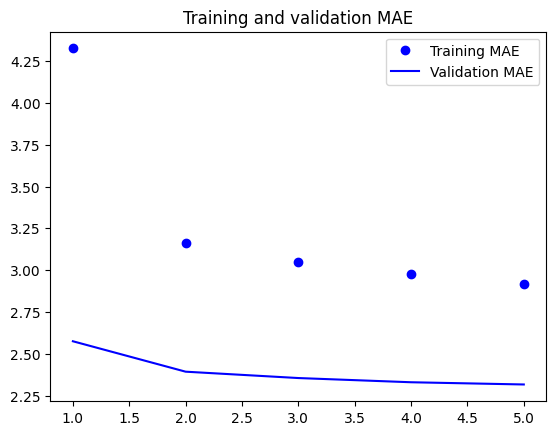

In [30]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()


#### Stacking recurrent layers

In [ ]:
inputs  = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x       = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x       = layers.GRU(32, recurrent_dropout=0.5)(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model   = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_stacked_gru_dropout.keras", save_best_only=True
                                    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

#### Using bidirectional RNNs

In [ ]:
inputs  = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x       = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model   = keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
)

### Going even further